# Member 2 - Ridge Regression
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using Ridge Regression and identify a suitable regularization strength using hyperparameter tuning.

### Model Suitability
Ridge Regression is suitable for predicting the continuous target variable `charges`. It extends Linear Regression by adding L2 regularization, which penalizes large coefficients and can reduce overfitting.

It is particularly useful when input features are correlated or when a more stable linear model is required. The regularization strength is controlled by the `alpha` hyperparameter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())


print("\nTesting Data:")
display(test_df.head())


print("\nTraining Missing Values:",
      train_df.isnull().sum().sum())

print("Testing Missing Values:",
      test_df.isnull().sum().sum())

print("Training Duplicates:",
      train_df.duplicated().sum())

print("Testing Duplicates:",
      test_df.duplicated().sum())


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Missing Values: 0
Testing Missing Values: 0
Training Duplicates: 0
Testing Duplicates: 0


In [4]:
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
The model is evaluated using:

- **MAE:** Measures the average absolute prediction error. Lower values indicate better performance.
- **RMSE:** Measures prediction error while giving a larger penalty to large errors. Lower values indicate better performance.
- **R²:** Measures how much variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation and Hyperparameter Tuning
Five-fold cross-validation is used during GridSearchCV. The main hyperparameter tuned in Ridge Regression is `alpha`, which controls the strength of L2 regularization.

The following alpha values are evaluated:

`0.001, 0.01, 0.1, 1, 10, 100, 1000`

A small alpha applies weak regularization, while a larger alpha applies stronger regularization. GridSearchCV identifies the alpha value with the best cross-validation performance.

### Implementation
Scikit-learn `Ridge` is used to build the model and `GridSearchCV` is used for hyperparameter tuning. A baseline Ridge model with `alpha=1.0` is first evaluated and then compared with the tuned Ridge model.

In [6]:
ridge_baseline = Ridge(
    alpha=1.0
)


ridge_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    ridge_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "Ridge Regression - Baseline (alpha=1.0)",
    y_test,
    baseline_predictions
)


Ridge Regression - Baseline (alpha=1.0)
--------------------------------------------------
MAE  : 4212.5449
RMSE : 5993.1050
R²   : 0.8045


In [7]:
# Hyperparameter values to test
param_grid = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}


ridge_model = Ridge()


grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Alpha:",
    grid_search.best_params_["alpha"]
)

print(
    "Best Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Alpha: 1
Best Cross-Validation RMSE: 6121.690585363275


In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)


alpha_results = pd.DataFrame({
    "Alpha":
        cv_results["param_alpha"].astype(float),

    "Mean_Train_RMSE":
        -cv_results["mean_train_score"],

    "Mean_CV_RMSE":
        -cv_results["mean_test_score"],

    "CV_RMSE_STD":
        cv_results["std_test_score"]
})


alpha_results = (
    alpha_results
    .sort_values("Alpha")
    .reset_index(drop=True)
)


print("Ridge Alpha Tuning Results:")

display(alpha_results)

Ridge Alpha Tuning Results:


,Alpha,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,0.001,6078.083277,6123.285112,376.686559
1,0.010,6078.083321,6123.266044,376.723135
2,0.100,6078.087779,6123.080239,377.088874
3,1.000,6078.519518,6121.690585,380.740057
4,10.000,6113.313395,6143.317808,414.414270
5,100.000,7237.945791,7243.866772,495.151554
6,1000.000,10240.217437,10246.483903,456.890373


In [9]:
best_ridge_model = (
    grid_search.best_estimator_
)


best_alpha = (
    grid_search.best_params_["alpha"]
)


tuned_predictions = (
    best_ridge_model.predict(
        X_test
    )
)


tuned_result = evaluate_model(
    f"Ridge Regression - Tuned (alpha={best_alpha})",
    y_test,
    tuned_predictions
)


Ridge Regression - Tuned (alpha=1)
--------------------------------------------------
MAE  : 4212.5449
RMSE : 5993.1050
R²   : 0.8045


In [10]:
ridge_results = pd.DataFrame([
    baseline_result,
    tuned_result
])


ridge_results = (
    ridge_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Baseline vs Tuned Ridge Regression:"
)

display(
    ridge_results
)

Baseline vs Tuned Ridge Regression:


,Model,MAE,RMSE,R2
0,Ridge Regression - Baseline (alpha=1.0),4212.544883,5993.105048,0.804538
1,Ridge Regression - Tuned (alpha=1),4212.544883,5993.105048,0.804538


In [11]:
cv_scores = cross_val_score(

    best_ridge_model,

    X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error"
)


cv_rmse_scores = -cv_scores


print("Final Model - 5-Fold CV RMSE Scores:")


for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Final Model - 5-Fold CV RMSE Scores:
Fold 1: 6817.6901
Fold 2: 5749.7426
Fold 3: 5802.3126
Fold 4: 6123.8908
Fold 5: 6114.8168

Mean CV RMSE: 6121.6906
CV RMSE Standard Deviation: 380.7401


In [12]:
coefficient_df = pd.DataFrame({
    "Feature":
        X_train.columns,

    "Coefficient":
        best_ridge_model.coef_
})


coefficient_df[
    "Absolute_Coefficient"
] = (
    coefficient_df[
        "Coefficient"
    ].abs()
)


coefficient_df = (
    coefficient_df
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    f"Ridge Coefficients "
    f"(alpha={best_alpha}):"
)

display(
    coefficient_df
)

Ridge Coefficients (alpha=1):


,Feature,Coefficient,Absolute_Coefficient
0,smoker_yes,22960.327577,22960.327577
1,age,3443.114179,3443.114179
2,bmi,1894.046474,1894.046474
3,children,636.742141,636.742141
4,region_southeast,-450.287290,450.287290
5,sex_male,-75.917755,75.917755
6,age_bmi_interaction,24.609094,24.609094


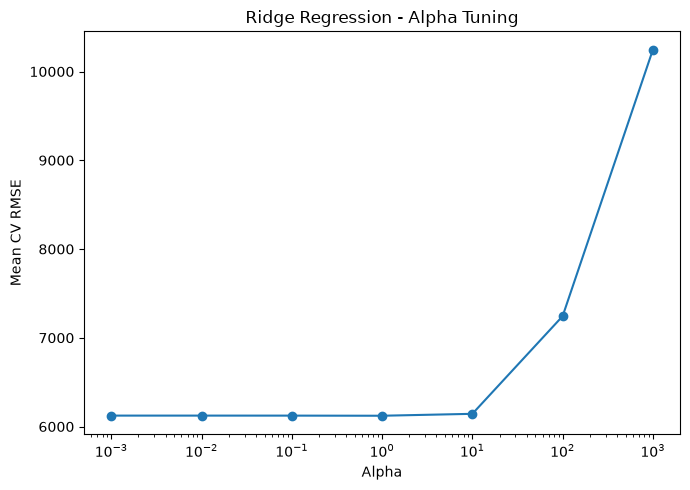

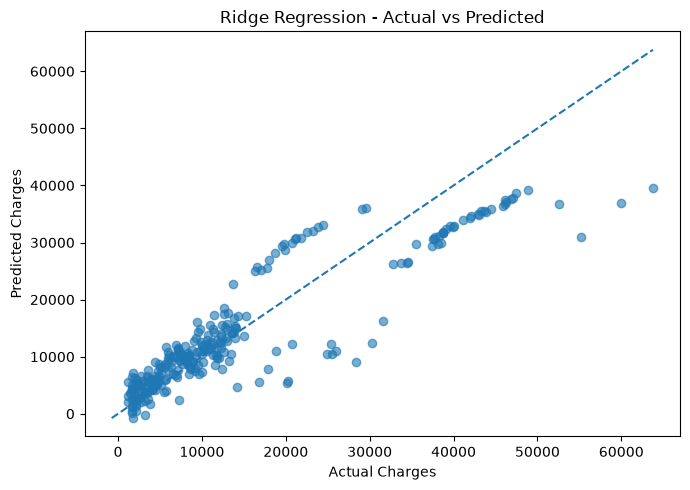

In [13]:
# Alpha vs Cross-Validation RMSE
plt.figure(
    figsize=(7, 5)
)


plt.plot(
    alpha_results["Alpha"],
    alpha_results["Mean_CV_RMSE"],
    marker="o"
)


plt.xscale("log")

plt.xlabel(
    "Alpha"
)

plt.ylabel(
    "Mean CV RMSE"
)

plt.title(
    "Ridge Regression - Alpha Tuning"
)

plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "ridge_alpha_tuning.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ----------------------------------------
# Actual vs Predicted
# ----------------------------------------

plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "Ridge Regression - Actual vs Predicted"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "ridge_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Save baseline vs tuned results
ridge_results.to_csv(

    RESULT_PATH
    / "ridge_results.csv",

    index=False
)


# Save all alpha tuning results
alpha_results.to_csv(

    RESULT_PATH
    / "ridge_tuning_results.csv",

    index=False
)


# Save final Ridge result for group comparison
best_ridge_result = pd.DataFrame([
    {
        "Model":
            "Ridge Regression",

        "Best_Configuration":
            f"alpha={best_alpha}",

        "MAE":
            tuned_result["MAE"],

        "RMSE":
            tuned_result["RMSE"],

        "R2":
            tuned_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_ridge_result.to_csv(

    RESULT_PATH
    / "ridge_best.csv",

    index=False
)


print("Ridge Model Results:")
display(ridge_results)


print("\nRidge Hyperparameter Tuning Results:")
display(alpha_results)


print("\nBest Ridge Result:")
display(best_ridge_result)


print("\nResults saved successfully.")

print(
    "Saved:",
    RESULT_PATH / "ridge_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "ridge_tuning_results.csv"
)

print(
    "Saved:",
    RESULT_PATH / "ridge_best.csv"
)

Ridge Model Results:


,Model,MAE,RMSE,R2
0,Ridge Regression - Baseline (alpha=1.0),4212.544883,5993.105048,0.804538
1,Ridge Regression - Tuned (alpha=1),4212.544883,5993.105048,0.804538



Ridge Hyperparameter Tuning Results:


,Alpha,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,0.001,6078.083277,6123.285112,376.686559
1,0.010,6078.083321,6123.266044,376.723135
2,0.100,6078.087779,6123.080239,377.088874
3,1.000,6078.519518,6121.690585,380.740057
4,10.000,6113.313395,6143.317808,414.414270
5,100.000,7237.945791,7243.866772,495.151554
6,1000.000,10240.217437,10246.483903,456.890373



Best Ridge Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Ridge Regression,alpha=1,4212.544883,5993.105048,0.804538,6121.690585



Results saved successfully.
Saved: ..\results\model_results\ridge_results.csv
Saved: ..\results\model_results\ridge_tuning_results.csv
Saved: ..\results\model_results\ridge_best.csv


## Conclusion, Limitations and Improvements

### Conclusion
A baseline Ridge Regression model and multiple regularized Ridge configurations were evaluated. GridSearchCV with five-fold cross-validation was used to evaluate seven different `alpha` values and identify a suitable regularization strength.

The baseline and tuned models were compared using MAE, RMSE, and R². The tuned Ridge result is saved for the final group-level comparison with the other regression models.

### Limitations
- Ridge Regression still assumes approximately linear relationships between the predictors and target.
- It may not capture complex nonlinear patterns in insurance charges.
- Model performance depends on the selected regularization strength.
- Ridge shrinks coefficients but does not normally reduce them exactly to zero.

### Possible Improvements
- Test a wider or more focused range of `alpha` values.
- Investigate additional feature engineering and transformations.
- Compare Ridge with other regularized regression approaches.
- Compare the results with nonlinear models such as SVR, Decision Tree, Random Forest, and KNN.